In [120]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def custom_month_year_formatter(x, pos):
    date = mdates.num2date(x)
    if date.month == 1:
        return date.strftime('%Y')
    else:
        return date.strftime('%b')


matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['date.converter'] = 'concise'
matplotlib.rcParams['font.size'] = 10

colors = [
    '#E86C6D',
    '#EC9495',
    '#FDB631',
    '#9B9B6B',
    '#B9529F',
]

LINEAGES = [
    'XBB.1.5.X',
    'XBB.1.16.X',
    'XBB.1.9.X',
    'JN.1.X',
    'XEC.X',
]

colors_dict = dict(zip(LINEAGES, colors))

In [121]:
# Load point loma lineage prevalence data
thresh1 = 0.05
thresh2 = 0.20

#lineage_prevalence = pd.read_csv('../data/lineage-prevalence/PointLoma_sewage_seqs.csv')
lineage_prevalence = pd.read_csv('../data/point_loma_prevalence_smoothed.csv')

# Get min and max dates for which each lineage appears above N% prevalence
lineage_prevalence['Date'] = pd.to_datetime(lineage_prevalence['Date'])
lineage_prevalence = lineage_prevalence[LINEAGES + ['Date']]


print(lineage_prevalence.head())
lineage_dates_thresh1 = {}
lineage_dates_thresh2 = {}
y = 12
for lineage in LINEAGES:
    dates_t1 = lineage_prevalence[lineage_prevalence[lineage] >= thresh1]['Date']
    dates_t2 = lineage_prevalence[lineage_prevalence[lineage] >= thresh2]['Date']
    lineage_dates_thresh1[lineage] = (dates_t1.min(), dates_t1.max(), y, lineage)
    lineage_dates_thresh2[lineage] = (dates_t2.min(), dates_t2.max(), y, lineage)
    y += 0.3

   XBB.1.5.X  XBB.1.16.X  XBB.1.9.X  JN.1.X  XEC.X       Date
0   0.227837         0.0        0.0     0.0    0.0 2023-01-10
1   0.222147         0.0        0.0     0.0    0.0 2023-01-15
2   0.219507         0.0        0.0     0.0    0.0 2023-01-17
3   0.216614         0.0        0.0     0.0    0.0 2023-01-19
4   0.232863         0.0        0.0     0.0    0.0 2023-01-23


In [122]:
covar = pd.read_csv('../data/covar_clinical_detections.tsv', sep='\t')
covar = covar[covar['num_clinical_detections'] == 0]

covar['collection_date'] = pd.to_datetime(covar['collection_date'])
covar['len_mutations'] = covar['nt_mutations'].apply(lambda x:len(x.split(' ')))
covar = covar[covar['len_mutations'] > 1]

# select only nt_mutations that occur more than once
covar_counts = covar.groupby('nt_mutations').size().reset_index(name='counts')
covar = covar.merge(covar_counts, on='nt_mutations', how='left')
covar = covar[covar['counts'] > 1]


coverage = pd.read_csv('median_coverage_summary.tsv', sep='\t')
coverage['sample'] = coverage['sample'].str.split('.trimmed').str[0]

coverage = coverage.merge(covar[['sample', 'collection_date']], on='sample', how='right')
coverage['week'] = pd.to_datetime(coverage['collection_date']).dt.to_period('W')
coverage = coverage.groupby('week')['MedianCoverage'].mean().reset_index()


print("Unique cryptic mutations:", covar['nt_mutations'].nunique())

covar['week'] = covar['collection_date'].dt.to_period('W')



covar = covar.merge(coverage, on='week', how='left')
covar = covar.groupby(covar['week']).agg({'collection_date': 'count', 'MedianCoverage': 'mean'}).rename(
    columns={'collection_date': 'cryptic_count'}).reset_index()

#Normalize by median coverage
covar['cryptic_count'] = covar['cryptic_count'] / covar['MedianCoverage']

covar_monthly = covar.copy()
covar_monthly['month'] = covar_monthly['week'].dt.to_timestamp().dt.to_period('M')
covar_monthly = covar_monthly.groupby('month').agg({'cryptic_count': 'sum'}).reset_index()
covar_monthly['month'] = covar_monthly['month'].dt.to_timestamp()

# calculate fold change from november to december
november_count = covar_monthly[covar_monthly['month'] == '2023-11-01']['cryptic_count'].values[0]
feb_count = covar_monthly[covar_monthly['month'] == '2024-01-01']['cryptic_count'].values[0]
fold_change = feb_count / november_count
print(f"Fold change in cryptic lineage detections from November to December: {fold_change:.2f}x")


Unique cryptic mutations: 932
Fold change in cryptic lineage detections from November to December: 5.51x


In [123]:
# Load viral load data
encina_viral_load = pd.read_csv('qPCR/Encina_sewage_qPCR.csv')
encina_viral_load['week'] = pd.to_datetime(encina_viral_load['Sample_Date']).dt.to_period('W')
encina_viral_load = encina_viral_load.groupby('week').agg({'Mean viral gene copies/L': 'mean'}).reset_index()

point_loma_viral_load = pd.read_csv('qPCR/PointLoma_sewage_qPCR.csv')
point_loma_viral_load['week'] = pd.to_datetime(point_loma_viral_load['Sample_Date']).dt.to_period('W')
point_loma_viral_load = point_loma_viral_load.groupby('week').agg({'Mean viral gene copies/L': 'mean'}).reset_index()

south_bay_viral_load = pd.read_csv('qPCR/SouthBay_sewage_qPCR.csv')
south_bay_viral_load['week'] = pd.to_datetime(south_bay_viral_load['Sample_Date']).dt.to_period('W')
south_bay_viral_load = south_bay_viral_load.groupby('week').agg({'Mean viral gene copies/L': 'mean'}).reset_index()

# Average viral loads across all sites
viral_load = encina_viral_load.merge(point_loma_viral_load, on='week', how='outer', suffixes=('_encina', '_point_loma'))
viral_load = viral_load.merge(south_bay_viral_load, on='week', how='outer')
viral_load = viral_load.rename(columns={'Mean viral gene copies/L': 'Mean viral gene copies/L_south_bay'})
viral_load['avg_viral_load'] = viral_load[['Mean viral gene copies/L_encina', 'Mean viral gene copies/L_point_loma', 'Mean viral gene copies/L_south_bay']].mean(axis=1)

covar = covar.merge(viral_load[['week', 'avg_viral_load']], on='week', how='left')

# Apply rolling average to smooth data
covar['cryptic_count'] = covar['cryptic_count'].rolling(window=4, min_periods=1).mean()
covar['avg_viral_load'] = covar['avg_viral_load'].rolling(window=4, min_periods=1).mean()

covar['week_start'] = covar['week'].dt.start_time
covar

/tmp/ipykernel_1960510/3028458687.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  encina_viral_load['week'] = pd.to_datetime(encina_viral_load['Sample_Date']).dt.to_period('W')
/tmp/ipykernel_1960510/3028458687.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  point_loma_viral_load['week'] = pd.to_datetime(point_loma_viral_load['Sample_Date']).dt.to_period('W')
/tmp/ipykernel_1960510/3028458687.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  south_bay_viral_load['week'] = pd.to_datetime(south_bay_viral_load['Sample_Date']).dt.to_period('W')


,week,cryptic_count,MedianCoverage,avg_viral_load,week_start
0,2022-12-26/2023-01-01,0.001858,10763.000000,4.589962e+06,2022-12-26
1,2023-01-02/2023-01-08,0.008348,9638.139860,2.956268e+06,2023-01-02
2,2023-01-09/2023-01-15,0.010576,9645.413793,2.245477e+06,2023-01-09
3,2023-01-16/2023-01-22,0.010724,8863.505051,1.927677e+06,2023-01-16
4,2023-01-23/2023-01-29,0.013684,22415.164495,9.592755e+05,2023-01-23
...,...,...,...,...,...
90,2024-11-11/2024-11-17,0.015802,1145.607692,2.425416e+06,2024-11-11
91,2024-11-18/2024-11-24,0.015774,1907.250000,2.410062e+06,2024-11-18
92,2024-11-25/2024-12-01,0.015416,1861.666667,2.941971e+06,2024-11-25
93,2024-12-02/2024-12-08,0.016024,548.000000,3.024290e+06,2024-12-02


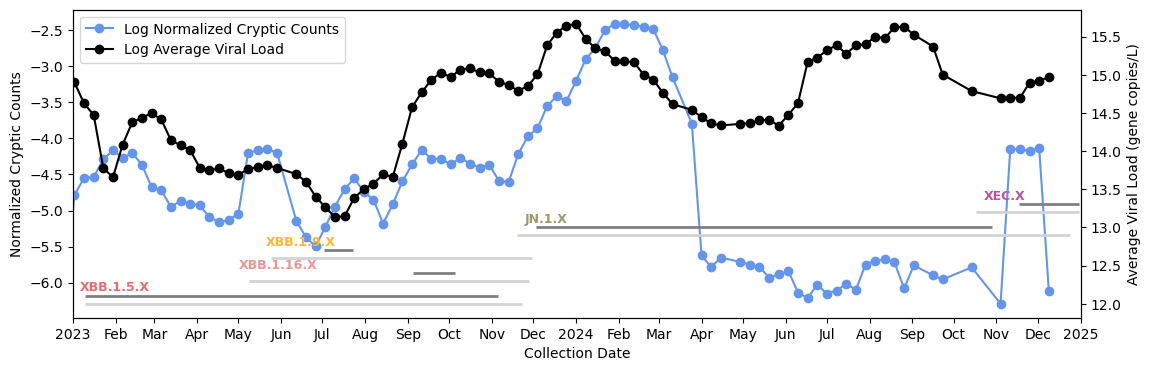

In [124]:
# Plot both cryptic counts and viral load over time with dual y-axes
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

# Plot main data
ax1.plot(
    covar['week_start'], 
    np.log(covar['cryptic_count']), 
    color='cornflowerblue', marker='o', label='Log Normalized Cryptic Counts'
)
ax2.plot(
    covar['week_start'], 
    np.log(covar['avg_viral_load']), 
    color='black', marker='o', label='Log Average Viral Load'
)

ax1.set_xlabel('Collection Date')
ax1.set_ylabel('Normalized Cryptic Counts')
ax2.set_ylabel('Average Viral Load (gene copies/L)')

# --- Add lineage prevalence bars with annotations ---
for start, end, y, label in lineage_dates_thresh1.values():
    # Draw horizontal line
    ax2.hlines(y, start, end, colors='lightgray', linewidth=2)

    ax2.text(
        start + pd.Timedelta(3, 'W'), y + 0.125,  # slight vertical offset
        label,
        ha='center', va='bottom',
        fontsize=9, color=colors_dict.get(label),
        rotation=0, fontweight='bold'
    )

# --- Add lineage prevalence bars with annotations ---
for start, end, y, label in lineage_dates_thresh2.values():
    # Draw horizontal line
    ax2.hlines(y + 0.1, start, end, colors='gray', linewidth=2)


# --- Combine legends for line plots only ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# --- Format x-axis ---
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(plt.FuncFormatter(custom_month_year_formatter))

# --- Fit limits ---
ax1.set_xlim(pd.to_datetime('2023-01-01'), pd.to_datetime('2025-01-01'))

plt.savefig(
    'plots/cryptics_viral_load_linechart.pdf',
    transparent=True,
    bbox_inches='tight',
    dpi=300
)

In [125]:
# Convert week periods to timestamps
covar['week'] = covar['week'].dt.start_time

def calculate_cryptic_percentage(start_date, weeks_offset=12):
    """Calculate percentage of cryptic lineages detected in time window around time window"""
    end_date = start_date + pd.Timedelta(weeks=weeks_offset)
    
    window_cryptics = covar[
        (covar['week'] >= start_date) & 
        (covar['week'] <= end_date)
    ]['cryptic_count'].sum()
    
    total_cryptics = covar['cryptic_count'].sum()
    return window_cryptics / total_cryptics * 100

# Find first date with prevalence > 20% for all lineages
first_detection_dates = {}
for lineage in LINEAGES:
    first_detection_dates[lineage] = lineage_prevalence[lineage_prevalence[lineage] > 0.9]['Date'].min()

print("First 20% prevalence dates:")
for lineage in LINEAGES:
    print(f"{lineage}: {first_detection_dates[lineage]}")

print("\nPercent normalized cryptic lineages within 12 weeks after 20% prevalence:")
for lineage in LINEAGES:
    percentage = calculate_cryptic_percentage(first_detection_dates[lineage])
    print(f"% {lineage}: {percentage:.2f}")

"""
First 20% prevalence dates:
XBB.1.5.X: 2023-01-10 00:00:00
XBB.1.16.X: 2023-09-05 00:00:00
XBB.1.9.X: 2023-07-02 00:00:00
JN.1.X: 2023-12-03 00:00:00
XEC.X: 2024-11-17 00:00:00

Percent Cryptic lineages within 12 weeks after 20% prevalence:
% XBB.1.5.X: 14.91
% XBB.1.16.X: 15.74
% XBB.1.9.X: 13.62
% JN.1.X: 34.17
% XEC.X: 1.76
"""

First 20% prevalence dates:
XBB.1.5.X: NaT
XBB.1.16.X: NaT
XBB.1.9.X: NaT
JN.1.X: 2024-01-25 00:00:00
XEC.X: NaT

Percent normalized cryptic lineages within 12 weeks after 20% prevalence:
% XBB.1.5.X: 0.00
% XBB.1.16.X: 0.00
% XBB.1.9.X: 0.00
% JN.1.X: 36.96
% XEC.X: 0.00


'\nFirst 20% prevalence dates:\nXBB.1.5.X: 2023-01-10 00:00:00\nXBB.1.16.X: 2023-09-05 00:00:00\nXBB.1.9.X: 2023-07-02 00:00:00\nJN.1.X: 2023-12-03 00:00:00\nXEC.X: 2024-11-17 00:00:00\n\nPercent Cryptic lineages within 12 weeks after 20% prevalence:\n% XBB.1.5.X: 14.91\n% XBB.1.16.X: 15.74\n% XBB.1.9.X: 13.62\n% JN.1.X: 34.17\n% XEC.X: 1.76\n'